<a href="https://colab.research.google.com/github/Sunidhikusmi/Sales-Performance-Analysis/blob/main/SalesPerformanceAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Sales Performance Analysis

## Objective
Analyze sales performance across regions, categories, and time.
Identify:
- Best & worst performing products
- Regional performance
- Seasonality trends
- Tactical improvements for Alfido Tech

Dataset Source:
https://www.kaggle.com/datasets/bhanupratabiswas/superstore-sales

In [ ]:
## Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
import kagglehub

path = kagglehub.dataset_download("bhanupratapbiswas/superstore-sales")

print("Path to dataset files:", path)

100%|██████████| 478k/478k [00:00<00:00, 79.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bhanupratapbiswas/superstore-sales/versions/1


## Load Dataset


In [7]:
df = pd.read_csv("/content/superstore_final_dataset.csv", encoding='latin1')

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


## Data Overview

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [10]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


## Data Cleaning & Preparation

In [13]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert Order Date to datetime, specifying dayfirst=True
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)

# Extract time features
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()
df["Quarter"] = df["Order_Date"].dt.quarter

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Year,Month,Month_Name,Quarter
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,2016,10,October,4


## KPI Calculations

In [17]:
print(df.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Year', 'Month', 'Month_Name', 'Quarter'],
      dtype='object')


In [18]:
# Total Revenue
total_revenue = df["Sales"].sum()

# Average Order Value
aov = df.groupby("Order_ID")["Sales"].sum().mean()

print("Total Revenue:", round(total_revenue,2))
print("Average Order Value:", round(aov,2))

print("\nNote: Profit and conversion metrics not available in dataset")

Total Revenue: 2261536.78
Average Order Value: 459.48

Note: Profit and conversion metrics not available in dataset


### KPI Insights
- Total Revenue shows overall business scale.
- AOV shows customer purchase behavior.
- Conversion metrics not available in dataset.

Revenue Growth Analysis

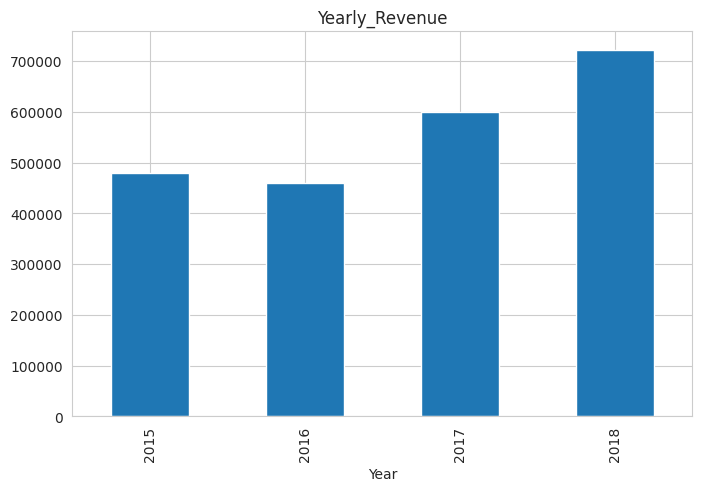

Year-over-Year Growth %:
Year
2015          NaN
2016    -4.255484
2017    30.636812
2018    20.303396
Name: Sales, dtype: float64


In [22]:
yearly_sales = df.groupby("Year")["Sales"].sum()

growth_rate = yearly_sales.pct_change() * 100

yearly_sales.plot(kind="bar", figsize=(8,5))
plt.title("Yearly_Revenue")
plt.show()

print("Year-over-Year Growth %:")
print(growth_rate)

## Monthly Seasonality Analysis

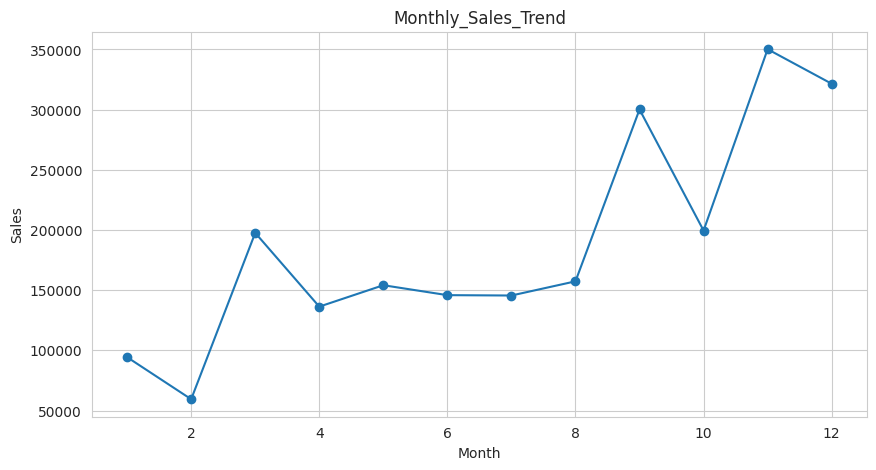

In [23]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot(marker="o", figsize=(10,5))
plt.title("Monthly_Sales_Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## Region Performance

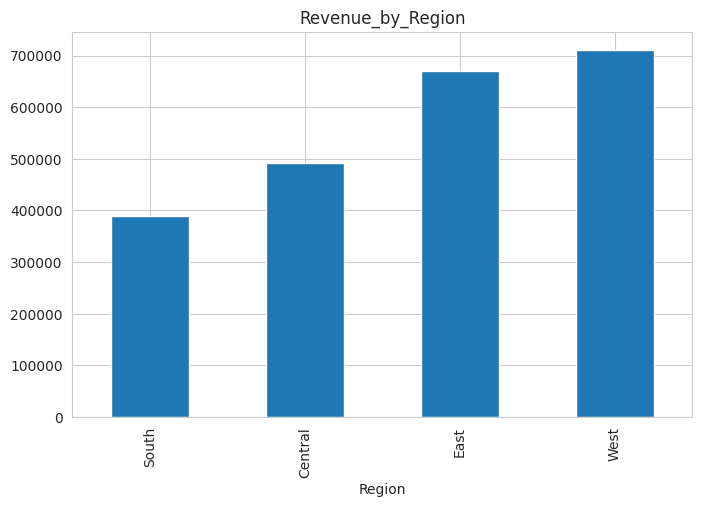

In [24]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

region_sales.plot(kind="bar", figsize=(8,5))
plt.title("Revenue_by_Region")
plt.show()

## Category Performance

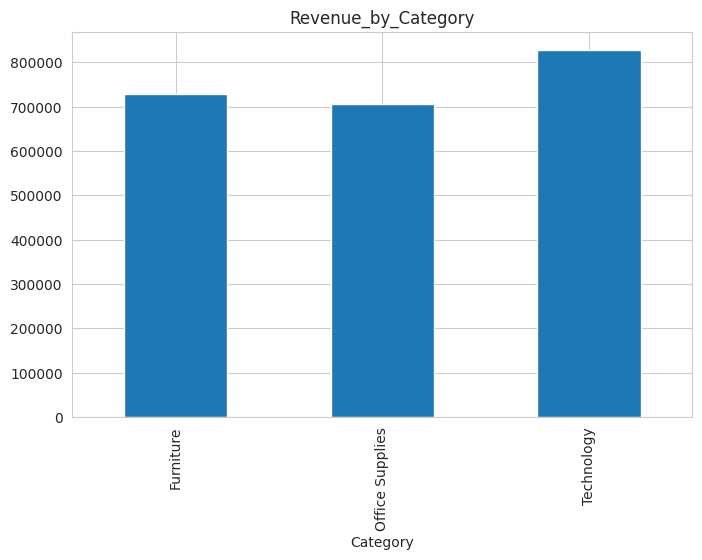

In [25]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar", figsize=(8,5))
plt.title("Revenue_by_Category")
plt.show()

## Top 10 Products

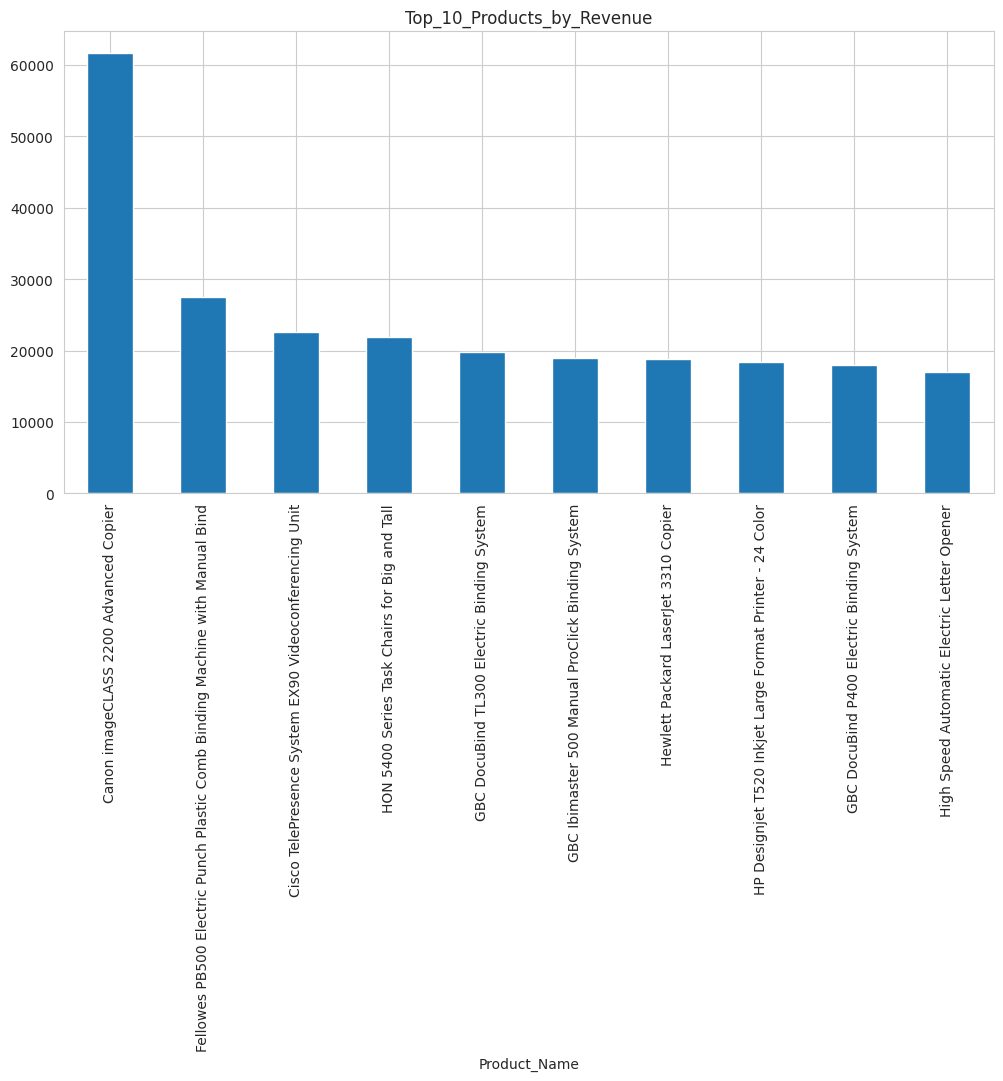

,Sales
Product_Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color,18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [26]:
top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar", figsize=(12,6))
plt.title("Top_10_Products_by_Revenue")
plt.show()

top_products

## Segment Analysis

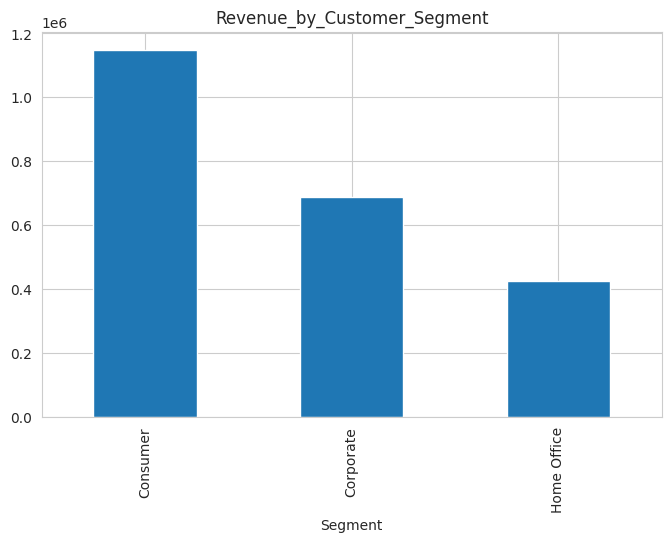

In [27]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales.plot(kind="bar", figsize=(8,5))
plt.title("Revenue_by_Customer_Segment")
plt.show()

## Order Frequemcy Analysis (Customer Behavior Insight)

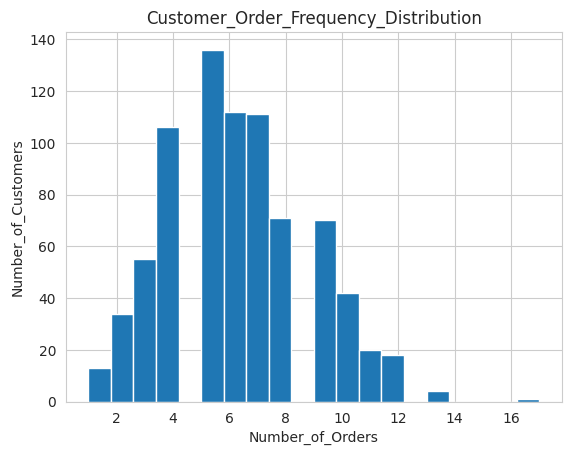

In [28]:
orders_per_customer = df.groupby("Customer_ID")["Order_ID"].nunique()

plt.hist(orders_per_customer, bins=20)
plt.title("Customer_Order_Frequency_Distribution")
plt.xlabel("Number_of_Orders")
plt.ylabel("Number_of_Customers")
plt.show()

## Strategic Recommendations

1. Focus marketing on highest revenue region.
2. Promote top-performing products with bundled offers.
3. Create loyalty programs for repeat customers.
4. Target underperforming regions with localized campaigns.
5. Launch special campaigns during peak months identified in seasonality analysis.

## Conclusion

The analysis identified:
- Revenue concentration in specific regions
- High-performing product categories
- Seasonal revenue peaks
- Customer segment contribution

This enables data-driven decisions for pricing, marketing, and expansion strategy.